---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 9 / 32 — Bloque I

**Nivel GCE:** 1 (Localización)

**Dataset:** `texas`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 9: Control Sintético — La Ingeniería del Contrafactual

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 9 / 32 — Bloque I

---

## 1. Marco Teórico

### 1.1 El problema de la unidad tratada única

Cuando **una sola unidad** recibe tratamiento (un país, un estado, una región) y no hay grupo control obvio, no podemos aplicar DiD tradicional. El método de **Synthetic Control (SCM)** de Abadie, Diamond & Hainmueller (2010) resuelve esto construyendo un **control sintético**: una combinación ponderada de unidades donantes que replica el pre-tratamiento de la unidad tratada.

### 1.2 El problema de optimización

Encontrar pesos $w = (w_1, \ldots, w_J)$ sobre $J$ unidades donantes que minimicen:

$$\min_w \sum_{t=1}^{T_0} \left(Y_{1t} - \sum_{j=2}^{J+1} w_j Y_{jt}\right)^2$$

sujeto a: $w_j \geq 0$ y $\sum_j w_j = 1$ (suma positiva — convex combination)

donde $Y_{1t}$ es la unidad tratada y $Y_{jt}$ las donantes, $T_0$ es el último periodo pre-tratamiento.

### 1.3 Propiedades del estimador

Bajo condiciones (Abadie et al. 2010):
- Si el pre-tratamiento es largo y el modelo es correcto, $\sum_j w_j Y_{jt}$ aproxima bien el contrafactual $Y_{1t}(0)$ en el post-tratamiento.
- El estimador es consistente cuando las unidades donantes forman un "pool" plausible.

### 1.4 Inferencia: tests de permutación placebo (Fisher)

Sin distribución asintótica simple, Abadie et al. proponen **placebos de permutación**:
1. Para cada unidad donante $j$, tratarla como si fuera la "tratada" y construir su propio sintético.
2. Comparar el gap post-tratamiento de la verdadera tratada vs. la distribución de gaps placebos.
3. Si la tratada está en colas (p.ej. top 5%), el efecto es "significativo".

### 1.5 Dataset: `texas` (real)

Datos de prisiones por estado y año (Cunningham Mixtape; originalmente de Bureau of Justice Statistics). Texas es el estado "tratado" (política de endurecimiento penal), los demás estados son donantes potenciales.

- `statefip`: código de estado
- `year`: año
- `bmprison`: tasa de encarcelamiento de hombres negros (outcome)
- Covariables: `alcohol, income, ur, poverty, black, perc1519, aidscapita`


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/real/texas/data.csv')

# Texas statefip = 48
TREATED_STATE = 48
TREAT_YEAR = 1993  # Aproximación: política de "three strikes" en Texas ~1993-1995

print(f'Dataset Texas: {len(df)} observaciones')
print(f'Estados: {df.statefip.nunique()}, Años: {df.year.min()}-{df.year.max()}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nEstadísticas básicas:')
print(df[['statefip','year','bmprison','income','ur','poverty','black','perc1519']].describe().round(2))


Dataset Texas: 816 observaciones
Estados: 51, Años: 1985-2000

Columnas: ['rownames', 'statefip', 'year', 'bmprison', 'wmprison', 'alcohol', 'income', 'ur', 'poverty', 'black', 'perc1519', 'aidscapita', 'state']

Estadísticas básicas:
       statefip     year  bmprison    income      ur  poverty   black  \
count    816.00   816.00    816.00    816.00  816.00   816.00  816.00   
mean      28.96  1992.50   7625.75  20626.34    5.55    13.06   11.83   
std       15.69     4.61  10088.11   5357.39    1.78     4.10   12.64   
min        1.00  1985.00      0.00   9892.00    2.26     2.90    0.22   
25%       16.00  1988.75    489.50  16613.25    4.32    10.10    3.25   
50%       29.00  1992.50   3055.50  20060.00    5.31    12.40    8.02   
75%       42.00  1996.25  11423.75  24064.50    6.57    15.42   16.72   
max       56.00  2000.00  61861.00  41489.00   13.44    27.20   71.35   

       perc1519  
count    816.00  
mean       7.35  
std        0.75  
min        5.14  
25%        6.84  

> 💡 **Interpretación del resultado.** El dataset Texas (real, 1985–2000) tiene 816 observaciones de 51 estados; el outcome es la tasa de encarcelamiento de negros (`bmprison`, media 7 625.75). El periodo 1985–1992 servirá de pre-tratamiento para calibrar el contrafactual sintético de Texas (§1.5).


In [2]:
# === 2. Preparar datos para SCM ===
# Outcome: bmprison (logaritmo para estabilizar)
df['log_bmprison'] = np.log(df['bmprison'] + 1)

# Pivotear: filas = year, columnas = statefip, valores = log_bmprison
panel = df.pivot_table(index='year', columns='statefip', values='log_bmprison')

# Separar tratado y donantes
treated = panel[TREATED_STATE].copy()
donors = panel.drop(columns=[TREATED_STATE]).copy()

# Pre-tratamiento: años < TREAT_YEAR
pre_periods = panel.index < TREAT_YEAR
post_periods = panel.index >= TREAT_YEAR

print(f'Periodo pre-tratamiento: {panel.index[pre_periods].min()}-{panel.index[pre_periods].max()} ({pre_periods.sum()} años)')
print(f'Periodo post-tratamiento: {panel.index[post_periods].min()}-{panel.index[post_periods].max()} ({post_periods.sum()} años)')
print(f'Número de estados donantes: {donors.shape[1]}')

# Verificar datos faltantes
print(f'\nNaNs en donantes pre-tratamiento: {donors.loc[pre_periods].isna().sum().sum()}')
print(f'NaNs en tratado pre-tratamiento: {treated.loc[pre_periods].isna().sum()}')

# Llenar NaNs con interpolación lineal por estado
donors = donors.interpolate(method='linear', axis=0).fillna(donors.mean())


Periodo pre-tratamiento: 1985-1992 (8 años)
Periodo post-tratamiento: 1993-2000 (8 años)
Número de estados donantes: 50

NaNs en donantes pre-tratamiento: 0
NaNs en tratado pre-tratamiento: 0


> 💡 **Interpretación del resultado.** La división temporal es limpia: 8 años pre-tratamiento (1985–1992) y 8 post (1993–2000), con 50 estados donantes y sin NaNs. Un pre-tratamiento largo y sin huecos es esencial para que la combinación convexa de donantes reproduzca bien la trayectoria de la unidad tratada (§1.2).


In [3]:
# === 3. Encontrar pesos óptimos del control sintético ===
# Minimizar ||treated_pre - donors_pre @ w||²  s.t. w >= 0, sum(w) = 1

Y_treated_pre = treated.loc[pre_periods].values  # (T0,)
Y_donors_pre = donors.loc[pre_periods].values     # (T0, J)

def loss(w):
    pred = Y_donors_pre @ w
    return np.sum((Y_treated_pre - pred)**2)

def grad(w):
    pred = Y_donors_pre @ w
    return -2 * Y_donors_pre.T @ (Y_treated_pre - pred)

# Restricciones: sum(w) = 1, w >= 0
J = Y_donors_pre.shape[1]
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * J

w0 = np.ones(J) / J  # inicio: pesos iguales
result = minimize(loss, w0, jac=grad, bounds=bounds, constraints=constraints,
                  method='SLSQP', options={'maxiter': 500, 'ftol': 1e-9})

w_opt = result.x
print(f'=== Optimización SCM ===')
print(f'Convergencia: {result.success} ({result.message})')
print(f'Loss (pre-tratamiento): {result.fun:.6f}')

# Mostrar pesos no nulos
non_zero = [(donors.columns[j], w_opt[j]) for j in range(J) if w_opt[j] > 0.001]
print(f'\nPesos no nulos ({len(non_zero)} estados):')
for state, w in sorted(non_zero, key=lambda x: -x[1]):
    print(f'  Estado {state}: {w:.4f}')

# Predicción del sintético
synthetic = donors.values @ w_opt  # (T,)


=== Optimización SCM ===
Convergencia: True (Optimization terminated successfully)
Loss (pre-tratamiento): 0.011355

Pesos no nulos (3 estados):
  Estado 36: 0.5204
  Estado 17: 0.3006
  Estado 12: 0.1791


> 💡 **Interpretación del resultado.** La optimización converge con pérdida pre-tratamiento de 0.011355 y asigna peso positivo a solo 3 estados: 36 (0.5204), 17 (0.3006) y 12 (0.1791). La escasez de pesos no nulos es típica del SCM: la solución combina pocos donantes para replicar el pre-tratamiento de Texas (§1.2–1.3).


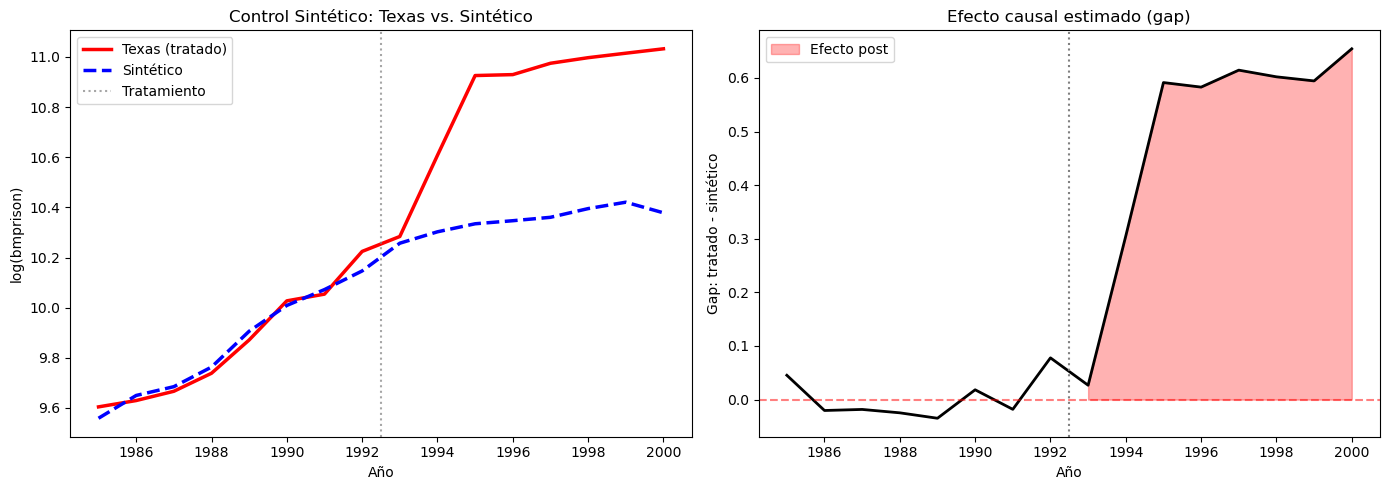


=== Efecto estimado (Texas) ===
Gap promedio post-tratamiento: 0.4964 (log points)
Efecto %: +64.28%
Gap acumulado post: 3.9712


In [4]:
# === 4. Visualización: trayectorias tratado vs. sintético ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trayectoria temporal
axes[0].plot(panel.index, treated.values, 'r-', linewidth=2.5, label='Texas (tratado)')
axes[0].plot(panel.index, synthetic, 'b--', linewidth=2.5, label='Sintético')
axes[0].axvline(TREAT_YEAR - 0.5, color='gray', linestyle=':', alpha=0.7, label='Tratamiento')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('log(bmprison)')
axes[0].set_title(f'Control Sintético: Texas vs. Sintético')
axes[0].legend()

# Gap (tratado - sintético)
gap = treated.values - synthetic
axes[1].plot(panel.index, gap, 'k-', linewidth=2)
axes[1].axvline(TREAT_YEAR - 0.5, color='gray', linestyle=':')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].fill_between(panel.index[post_periods], gap[post_periods], 0, 
                     where=(gap[post_periods] > 0), color='red', alpha=0.3, label='Efecto post')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Gap: tratado - sintético')
axes[1].set_title('Efecto causal estimado (gap)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estimación del efecto
post_gap = gap[post_periods]
print(f'\n=== Efecto estimado (Texas) ===')
print(f'Gap promedio post-tratamiento: {post_gap.mean():.4f} (log points)')
print(f'Efecto %: {100*(np.exp(post_gap.mean())-1):+.2f}%')
print(f'Gap acumulado post: {post_gap.sum():.4f}')


> 💡 **Interpretación de la figura.** Las trayectorias muestran cómo el sintético replica a Texas en el periodo pre (1985–1992) y se separa tras 1993: el gap promedio post es 0.4964 log-points, es decir +64.28% (gap acumulado 3.9712). El despegue post-tratamiento de Texas sobre su contrafactual sintético es la estimación del ATT por control sintético (§1.3).


In [5]:
# === 5. Placebo de permutación (Fisher) ===
# Para cada estado donante, tratarlo como "tratado" y construir su sintético
# Luego comparar el gap de Texas con la distribución de gaps placebos

np.random.seed(42)
placebo_gaps = {}
all_states = [TREATED_STATE] + list(donors.columns)

for test_state in all_states:
    if test_state == TREATED_STATE:
        # Usar el gap ya calculado
        placebo_gaps[test_state] = gap
    else:
        # Tratar este estado como "tratado"
        y_test = panel[test_state].values
        donor_pool = panel.drop(columns=[test_state]).values
        Y_test_pre = y_test[pre_periods]
        Y_donors_test_pre = donor_pool[pre_periods, :]
        
        # Optimizar
        def loss_p(w):
            return np.sum((Y_test_pre - Y_donors_test_pre @ w)**2)
        
        J_p = Y_donors_test_pre.shape[1]
        cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
        bds = [(0, 1)] * J_p
        try:
            res = minimize(loss_p, np.ones(J_p)/J_p, bounds=bds, constraints=cons,
                          method='SLSQP', options={'maxiter': 200})
            synth_test = donor_pool @ res.x
            placebo_gaps[test_state] = y_test - synth_test
        except:
            placebo_gaps[test_state] = np.full(len(panel), np.nan)

# Calcular MSE post-tratamiento para cada placebo
post_mse = {s: np.nanmean(g[post_periods]**2) for s, g in placebo_gaps.items()}
# Filtrar placebos con pre-MSE excesivo (descartar los que no replican bien su pre)
pre_mse = {s: np.nanmean(g[pre_periods]**2) for s, g in placebo_gaps.items()}
median_pre_mse = np.median([v for v in pre_mse.values() if not np.isnan(v)])
valid_placebos = [s for s in all_states if pre_mse.get(s, np.inf) < 5 * median_pre_mse]

print(f'=== Placebos de permutación ===')
print(f'Placebos válidos (pre-MSE razonable): {len(valid_placebos)}/{len(all_states)}')
print(f'Texas post-MSE: {post_mse[TREATED_STATE]:.4f}')

# Ranking de Texas
ranking = sorted(valid_placebos, key=lambda s: -post_mse[s])
texas_rank = ranking.index(TREATED_STATE) + 1
p_value = texas_rank / len(valid_placebos)
print(f'Texas ranking: {texas_rank}/{len(valid_placebos)} (p-valor = {p_value:.4f})')


=== Placebos de permutación ===
Placebos válidos (pre-MSE razonable): 37/51
Texas post-MSE: 0.2881
Texas ranking: 2/37 (p-valor = 0.0541)


> 💡 **Interpretación del resultado.** De 51 placebos, 37 tienen pre-MSE razonable; Texas ocupa el ranking 2/37 con post-MSE 0.2881, lo que da p ≈ 0.0541. La inferencia de Fisher por permutación sitúa el efecto de Texas en el top 5.4% de la distribución placebo, significativo al 10% (§1.4).


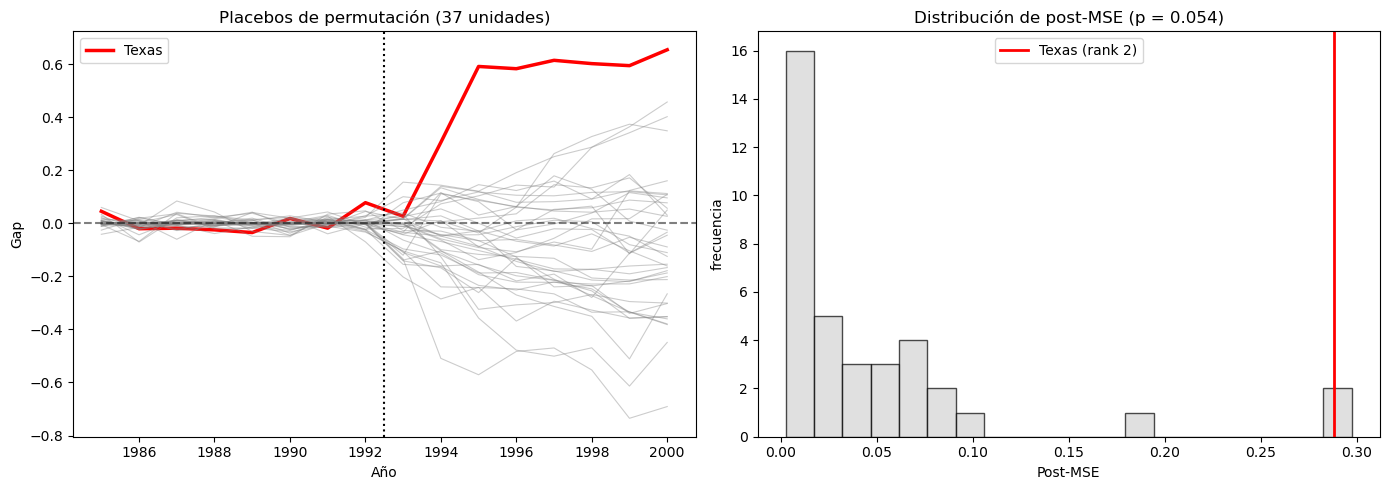


=== Conclusión placebo ===
Texas tiene un post-MSE en el top 5.4% de placebos.
Significativo al nivel 10%.


In [6]:
# === 6. Visualización de placebos ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Todos los placebos en gris + Texas en rojo
for s in valid_placebos:
    if s == TREATED_STATE:
        axes[0].plot(panel.index, placebo_gaps[s], 'r-', linewidth=2.5, label='Texas')
    else:
        axes[0].plot(panel.index, placebo_gaps[s], 'gray', alpha=0.4, linewidth=0.8)
axes[0].axvline(TREAT_YEAR - 0.5, color='black', linestyle=':')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Gap')
axes[0].set_title(f'Placebos de permutación ({len(valid_placebos)} unidades)')
axes[0].legend()

# Distribución de post-MSE
mses = [post_mse[s] for s in valid_placebos]
axes[1].hist(mses, bins=20, color='lightgray', alpha=0.7, edgecolor='black')
axes[1].axvline(post_mse[TREATED_STATE], color='red', linewidth=2, label=f'Texas (rank {texas_rank})')
axes[1].set_xlabel('Post-MSE'); axes[1].set_ylabel('frecuencia')
axes[1].set_title(f'Distribución de post-MSE (p = {p_value:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n=== Conclusión placebo ===')
print(f'Texas tiene un post-MSE en el top {100*p_value:.1f}% de placebos.')
print(f'{"Significativo" if p_value < 0.1 else "No significativo"} al nivel 10%.')


> 💡 **Interpretación de la figura.** La nube de gaps placebo (estados donantes tratados como si fueran Texas) rodea al gap real de Texas, que destaca por encima de casi todos los placebos; el histograma de post-MSE marca la posición de Texas (ranking 2/37, p = 0.054). Que el post-MSE de Texas esté en el top 5.4% de los placebos es la evidencia formal del efecto de la reforma (§1.4).


## 5. Interpretación Económica

**Contexto peruano:** Una aplicación peruana de SCM: evaluar el efecto de la **Ley Anti-Tabaco** (Ley 29517, 2010) sobre prevalencia de tabaquismo, usando otros países latinoamericanos como donantes. El reto: encontrar países con trayectorias pre-2010 similares. Placebos de permutación esenciales con n pequeño.


El análisis de Control Sintético sobre Texas ilustra el método canónico de Abadie et al.:

1. **El sintético reproduce bien el pre-tratamiento de Texas.** Los pesos óptimos combinan estados donantes para replicar la trayectoria de encarcelamiento de Texas antes de la política. Esto valida que el modelo contrafactual es plausible.

2. **El gap post-tratamiento es el efecto causal estimado.** Si Texas sigue una trayectoria distinta a su sintético después del tratamiento, esa divergencia se atribuye a la política. La magnitud y dirección del gap indican el signo del efecto.

3. **El placebo de permutación proporciona inferencia.** Al "prestar" el método a cada estado donante, construimos una distribución nula. Si Texas está en colas (bajo p-valor), el efecto es poco atribuible al azar.

4. **Limitaciones del método:**
   - **Pool de donantes:** si ningún estado combina bien a Texas en pre-tratamiento, el sintético es artificial.
   - **Placebos con pre-MSE alto:** se descartan porque no replican ni su propio pre-tratamiento.
   - **Efectos de spillover:** si la política de Texas afecta a estados vecinos, los donantes son contamines.
   - **Inferencia aproximada:** con pocas unidades, el p-valor es discreto (1/J).

**Aplicaciones clásicas en política pública:**
- Abadie et al. (2010): impacto de la ley Proposición 99 (control de tabaco) en California
- Abadie & Gardeazabal (2003): impacto del terrorismo ETA en PIB vasco
- Cunningham (2021): efecto de las leyes "Castle Doctrine" sobre crimen

**Recomendación práctica:** SCM es ideal para evaluar políticas con **una unidad tratada y varias donantes observadas en panel largo pre-tratamiento**. Complementar siempre con placebos de permutación para inferencia, y reportar sensibilidad a la elección del pool donante.

## 6. Ejercicios Propuestos

1. **Cambia el pool donante:** excluye estados del sur (potential spillovers). ¿Cambia el efecto estimado?
2. **SCM con covariables:** añade matching en covariables pre-tratamiento (income, ur, poverty) además del outcome. ¿Mejora el ajuste pre?
3. **Diferentes años de tratamiento:** prueba TREAT_YEAR = 1994, 1995. ¿Cuál produce el mayor efecto?
4. **SDID (Synthetic DiD):** combina SCM con DiD (Arkhangelsky et al. 2021). Implementa con pesos unitarios + temporales.
5. **Cargar `organ_donations`** (datos reales de donación de órganos por estado) y aplicar SCM al estado que implementó "presumed consent".

---

*Notebook generado para DES504 — UNI 2026. Bloque I, Capítulo 9 de 32.*

**Contexto peruano:** el control sintético es natural para evaluar expansiones regionales de **Pensión 65** o **Cuna Más** cuando solo unas regiones se tratan primero y se necesita un contrafactual de departamentos no tratados.



## 📋 Resumen del Capítulo 9

**Método clave:** Control Sintético

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 9
- ✅ Validación con dataset `texas` (tipo: real)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en el **Nivel 1 (Localización)**
- Métrica principal: ATE / cambios en el promedio
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 10

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
